In [ ]:
from google.colab import auth
auth.authenticate_user()



In [ ]:
from google.cloud import bigquery

client = bigquery.Client(project="gamingprofilesproject")

In [ ]:
query = """
WITH base AS (
  SELECT
    playerid,
    total_achievements,
    achievements_per_day,
    lifetime_days,
    DATE_DIFF(DATE '2024-12-29', last_activity, DAY) AS days_since_last_activity,
    CASE
      WHEN lifetime_days >= 7
      THEN LOG(1 + achievements_per_day)
      ELSE NULL
    END AS log_achievements_per_day
  FROM `gamingprofilesproject.playstation_final.players_activity`
)

SELECT
  playerid,

  -- ML Feature'lar
  total_achievements,
  log_achievements_per_day,
  lifetime_days,
  days_since_last_activity

FROM base
WHERE log_achievements_per_day IS NOT NULL
  AND lifetime_days >= 7;

"""

df = client.query(query).to_dataframe()
df.head()

,playerid,total_achievements,log_achievements_per_day,lifetime_days,days_since_last_activity
0,181306,22,0.00000,4568,112
1,3289605,6,0.00000,1326,504
2,4059033,33,0.00995,2598,456
3,118998,14,0.00995,1090,3457
4,4205944,32,0.00995,2498,63


In [ ]:
df.columns

Index(['playerid', 'total_achievements', 'log_achievements_per_day',
       'lifetime_days', 'days_since_last_activity'],
      dtype='object')

In [ ]:
df.shape
df.isna().sum()

,0
playerid,0
total_achievements,0
log_achievements_per_day,0
lifetime_days,0
days_since_last_activity,0


In [ ]:
df.dtypes

,0
playerid,Int64
total_achievements,Int64
log_achievements_per_day,float64
lifetime_days,Int64
days_since_last_activity,Int64


In [ ]:
import pandas as pd

num_cols = ["total_achievements", "log_achievements_per_day", "lifetime_days", "days_since_last_activity"]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.isna().sum()

,0
playerid,0
total_achievements,0
log_achievements_per_day,0
lifetime_days,0
days_since_last_activity,0


In [ ]:
df.dtypes

,0
playerid,Int64
total_achievements,Int64
log_achievements_per_day,float64
lifetime_days,Int64
days_since_last_activity,Int64


In [ ]:
df = df.dropna(subset=num_cols).copy()
df.shape

(4986, 5)

Aşırı uç değerleri baskılamak

In [ ]:
for c in num_cols:
    q_low = int(df[c].quantile(0.01))
    q_high = int(df[c].quantile(0.99))

    df[c] = df[c].clip(lower=q_low, upper=q_high)

**Feature Matrisi Oluştur (playerid hariç)**



In [ ]:
X = df[num_cols].copy()
X.head()

,total_achievements,log_achievements_per_day,lifetime_days,days_since_last_activity
0,45,0.00000,4568,112
1,45,0.00000,1326,504
2,45,0.00995,2598,456
3,45,0.00995,1090,3457
4,45,0.00995,2498,63


**Scale Et**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**En İyi k’yı Bul (Elbow + Silhouette)**

Elbow (Inertia)

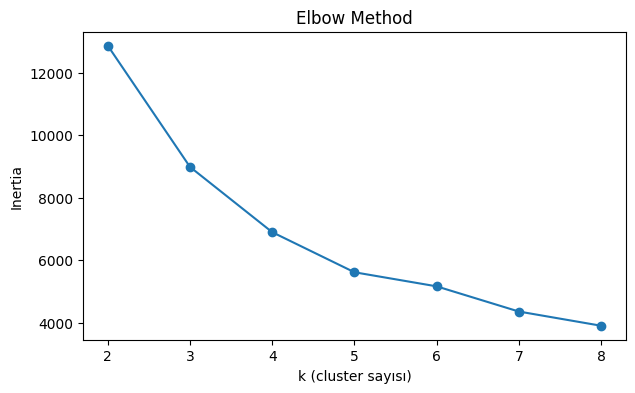

In [ ]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k (cluster sayısı)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

**Silhouette Score (daha güvenilir)**

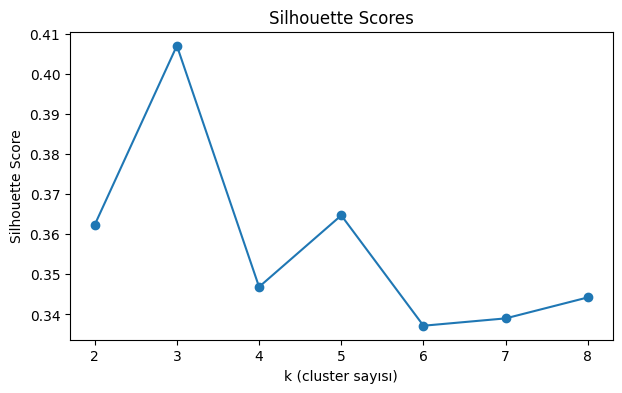

[(2, np.float64(0.36234442456743643)),
 (3, np.float64(0.40707938431107304)),
 (4, np.float64(0.346865217474065)),
 (5, np.float64(0.364724061917754)),
 (6, np.float64(0.337170884165595)),
 (7, np.float64(0.33900442415645937)),
 (8, np.float64(0.34424317815568245))]

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(list(k_values), sil_scores, marker="o")
plt.xlabel("k (cluster sayısı)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

list(zip(k_values, sil_scores))

**Final KMeans Modelini Eğit ve Label’ı Ekle**

In [ ]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(X_scaled)

df[["playerid", "cluster"]].head()

,playerid,cluster
0,181306,0
1,3289605,0
2,4059033,0
3,118998,2
4,4205944,0


Cluster dağılımı

In [ ]:
df["cluster"].value_counts()

,count
cluster,
0,3101
1,1381
2,504


**Cluster Profiling (En Önemli Kısım)**

In [ ]:
profile = df.groupby("cluster")[num_cols].agg(["mean", "median", "count"])
profile

total_achievements               log_achievements_per_day            \
                      mean  median count                     mean    median   
cluster                                                                       
0               1270.17317  1089.0  3101                 0.321883  0.292670   
1              7384.997828  5902.0  1381                 0.828883  0.858662   
2              1150.246032   542.0   504                 0.418297  0.329304   

              lifetime_days               days_since_last_activity          \
        count          mean  median count                     mean  median   
cluster                                                                      
0        3101   3236.367946  3075.0  3101               367.864237   104.0   
1        1381    4649.23244  4960.0  1381               251.574222    27.0   
2         504   1684.892857  1627.5   504              3346.662698  3341.5   

               
        count  
cluster        
0        3101  
1        1381  
2         504

Daha Okunur Tablo

In [ ]:
profile_simple = df.groupby("cluster")[num_cols].mean().round(3)
profile_simple

,total_achievements,log_achievements_per_day,lifetime_days,days_since_last_activity
cluster,,,,
0,1270.173,0.322,3236.368,367.864
1,7384.998,0.829,4649.232,251.574
2,1150.246,0.418,1684.893,3346.663


**Cluster’lara İsim Ver (Core/Casual/Dormant gibi)**

In [ ]:
cluster_names = {
    1: "Core",
    0: "Casual",
    2: "Dormant"
}

df["segment_ml"] = df["cluster"].map(cluster_names)

df[["playerid", "cluster", "segment_ml"]].head()
df["segment_ml"].value_counts()


,count
segment_ml,
Casual,3101
Core,1381
Dormant,504


**Hızlı Görselleştirme (2D)**

PCA ile 2 boyuta indir

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

df["pc1"] = X_2d[:, 0]
df["pc2"] = X_2d[:, 1]

df[["pc1", "pc2"]].head()

,pc1,pc2
0,-0.831143,-1.647109
1,-1.987632,-0.507114
2,-1.548263,-0.865990
3,-2.949888,1.590313
4,-1.459808,-1.107632


Scatter plot

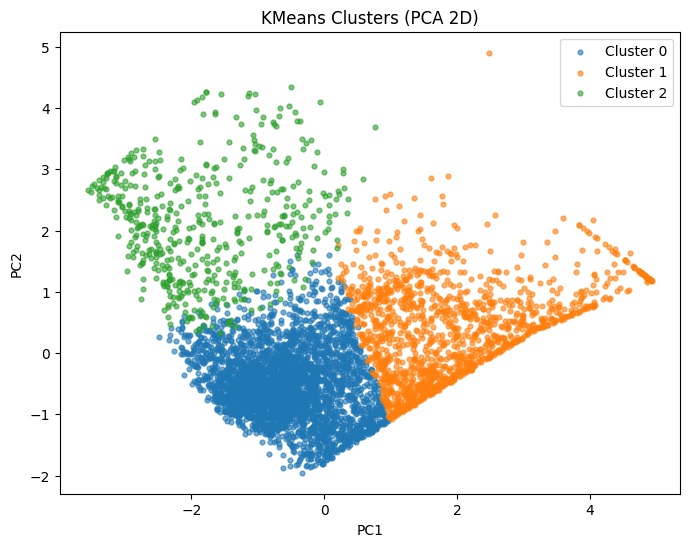

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for c in sorted(df["cluster"].unique()):
    tmp = df[df["cluster"] == c]
    plt.scatter(
        tmp["pc1"],
        tmp["pc2"],
        s=12,
        alpha=0.6,
        label=f"Cluster {c}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters (PCA 2D)")
plt.legend()
plt.show()

ML Segment (Core / Casual / Dormant) ile Scatter

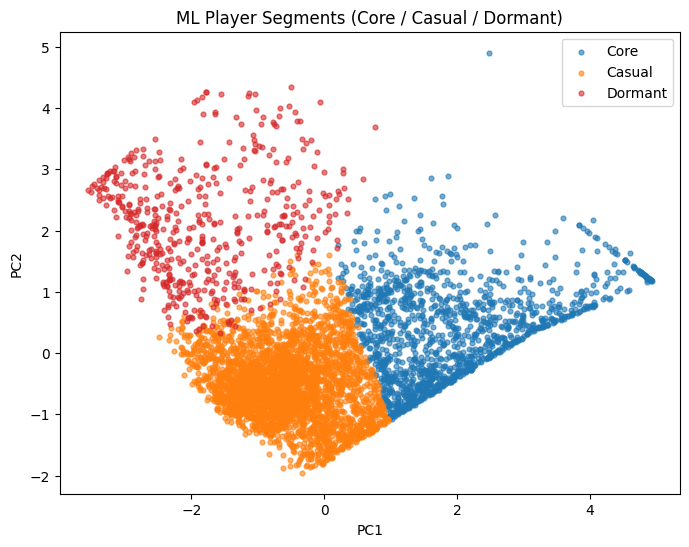

In [ ]:
plt.figure(figsize=(8, 6))

colors = {
    "Core": "#1f77b4",
    "Casual": "#ff7f0e",
    "Dormant": "#d62728"
}

for seg, color in colors.items():
    tmp = df[df["segment_ml"] == seg]
    plt.scatter(
        tmp["pc1"],
        tmp["pc2"],
        s=12,
        alpha=0.6,
        label=seg,
        color=color
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("ML Player Segments (Core / Casual / Dormant)")
plt.legend()
plt.show()

Feature Pair Scatter

Achievement Velocity vs Recency

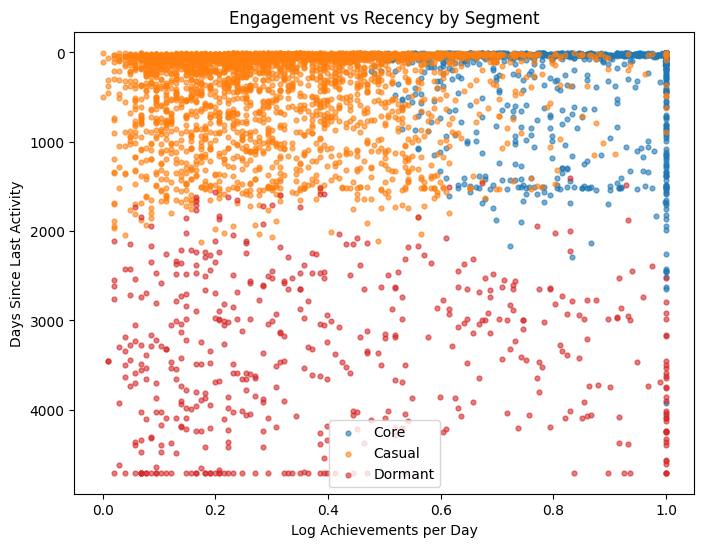

In [ ]:
plt.figure(figsize=(8, 6))

for seg, color in colors.items():
    tmp = df[df["segment_ml"] == seg]
    plt.scatter(
        tmp["log_achievements_per_day"],
        tmp["days_since_last_activity"],
        s=12,
        alpha=0.6,
        label=seg,
        color=color
    )

plt.xlabel("Log Achievements per Day")
plt.ylabel("Days Since Last Activity")
plt.title("Engagement vs Recency by Segment")
plt.legend()
plt.gca().invert_yaxis()  # Daha aktif yukarıda gözüksün
plt.show()

Lifetime vs Total Achievements

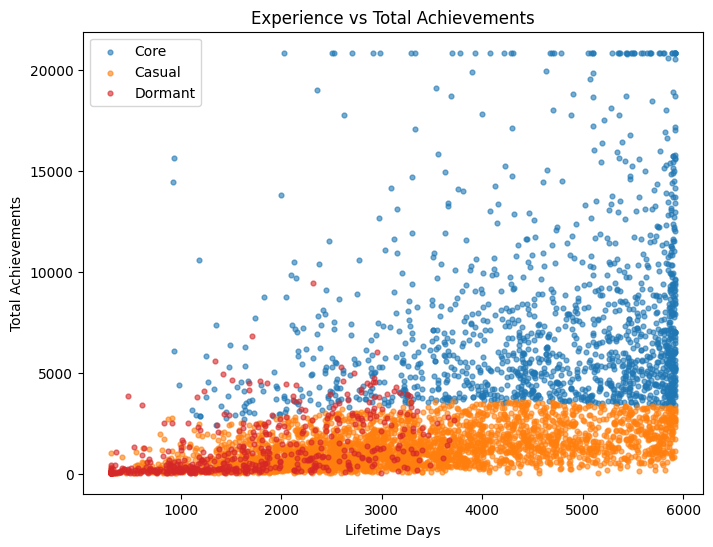

In [ ]:
plt.figure(figsize=(8, 6))

for seg, color in colors.items():
    tmp = df[df["segment_ml"] == seg]
    plt.scatter(
        tmp["lifetime_days"],
        tmp["total_achievements"],
        s=12,
        alpha=0.6,
        label=seg,
        color=color
    )

plt.xlabel("Lifetime Days")
plt.ylabel("Total Achievements")
plt.title("Experience vs Total Achievements")
plt.legend()
plt.show()

**CHURN ANALİZİ**

In [ ]:
query = """
WITH --ach_day_count
  obs_dates AS (
    SELECT obs_date
    FROM UNNEST([
      DATE '2024-07-01',
      DATE '2024-08-01',
      DATE '2024-09-01'
    ]) AS obs_date
  ),

  -- Daily activity:
  daily AS (
    SELECT
      playerid,
      DATE(date_acquired) AS activity_date,
      total_achievement AS achievements_earned
    FROM `gamingprofilesproject.playstation_clean.playstation_ach_day_count`
  ),

  -- İlk aktivite (lifetime için)
  first_seen AS (
    SELECT
      playerid,
      MIN(activity_date) AS first_activity_date
    FROM daily
    GROUP BY 1
  ),

  -- Observation date'e kadar feature'lar
  features AS (
    SELECT
      d.playerid,
      o.obs_date,

      MAX(IF(d.activity_date <= o.obs_date, d.activity_date, NULL)) AS last_activity_until_obs,

      DATE_DIFF(o.obs_date, f.first_activity_date, DAY) AS lifetime_days,

      SUM(IF(d.activity_date <= o.obs_date, d.achievements_earned, 0)) AS total_achievements,

      SUM(
        IF(
          d.activity_date BETWEEN DATE_SUB(o.obs_date, INTERVAL 29 DAY) AND o.obs_date,
          d.achievements_earned,
          0
        )
      ) AS ach_last_30d,

      DATE_DIFF(
        o.obs_date,
        MAX(IF(d.activity_date <= o.obs_date, d.activity_date, NULL)),
        DAY
      ) AS days_since_last_activity

    FROM daily d
    CROSS JOIN obs_dates o
    JOIN first_seen f USING (playerid)
    GROUP BY 1, 2, f.first_activity_date
  ),

  -- Velocity + flag
  features_enriched AS (
    SELECT
      *,
      SAFE_DIVIDE(ach_last_30d, 30) AS achievements_per_day_30d,
      LOG(1 + SAFE_DIVIDE(ach_last_30d, 30)) AS log_achievements_per_day,
      CASE WHEN days_since_last_activity <= 30 THEN 1 ELSE 0 END AS is_recent_active
    FROM features
  ),

  -- obs_date bazlı P75 threshold'lar
  thresholds AS (
    SELECT
      obs_date,
      APPROX_QUANTILES(total_achievements, 4)[OFFSET(3)] AS total_ach_p75,
      APPROX_QUANTILES(log_achievements_per_day, 4)[OFFSET(3)] AS log_ach_p75
    FROM features_enriched
    WHERE log_achievements_per_day IS NOT NULL
    GROUP BY 1
  ),

  -- Core score
  scored AS (
    SELECT
      fe.*,
      CASE WHEN fe.total_achievements >= t.total_ach_p75 THEN 1 ELSE 0 END AS high_total_achievement,
      CASE WHEN fe.log_achievements_per_day >= t.log_ach_p75 THEN 1 ELSE 0 END AS high_achievement_velocity,
      (
        CASE WHEN fe.days_since_last_activity <= 30 THEN 1 ELSE 0 END +
        CASE WHEN fe.total_achievements >= t.total_ach_p75 THEN 1 ELSE 0 END +
        CASE WHEN fe.log_achievements_per_day >= t.log_ach_p75 THEN 1 ELSE 0 END +
        CASE WHEN fe.lifetime_days >= 750 AND fe.days_since_last_activity <= 120 THEN 1 ELSE 0 END
      ) AS core_score
    FROM features_enriched fe
    LEFT JOIN thresholds t
    USING (obs_date)
  ),

  -- Label: obs_date sonrası 120 gün içinde hiç aktivite yoksa churn=1
  labels AS (
    SELECT
      s.playerid,
      s.obs_date,
      IF(
        COUNTIF(
          d.activity_date BETWEEN DATE_ADD(s.obs_date, INTERVAL 1 DAY)
          AND DATE_ADD(s.obs_date, INTERVAL 120 DAY)
        ) = 0,
        1,
        0
      ) AS churn_120
    FROM scored s
    LEFT JOIN daily d
      ON d.playerid = s.playerid
    GROUP BY 1, 2
  )

SELECT
  s.playerid,
  s.obs_date,

  -- MODELE GİRECEK FEATURE’LAR
  s.total_achievements,
  s.log_achievements_per_day,
  s.lifetime_days,
  s.core_score,
  s.is_recent_active,

  -- MODELE GİRMEYECEK (analiz için kalsın)
  s.days_since_last_activity,
  s.last_activity_until_obs,

  -- TARGET
  l.churn_120

FROM scored s
JOIN labels l
USING (playerid, obs_date);

"""

churn_ml = client.query(query).to_dataframe()
churn_ml.head()


,playerid,obs_date,total_achievements,log_achievements_per_day,lifetime_days,core_score,is_recent_active,days_since_last_activity,last_activity_until_obs,churn_120
0,417982,2024-07-01,2635,0.287682,5743,2,1,8,2024-06-23,0
1,3065998,2024-07-01,101446,4.184084,5216,4,1,0,2024-07-01,0
2,3800606,2024-07-01,23261,1.435085,4050,4,1,5,2024-06-26,0
3,2840014,2024-07-01,1222,0.000000,1643,1,0,104,2024-03-19,0
4,215854,2024-07-01,1702,0.757686,4503,3,1,0,2024-07-01,0


**1.2 Boyut & null kontrolü**

In [ ]:
churn_ml.shape
churn_ml.isna().sum()

,0
playerid,0
obs_date,0
total_achievements,0
log_achievements_per_day,0
lifetime_days,0
core_score,0
is_recent_active,0
days_since_last_activity,1
last_activity_until_obs,1
churn_120,0


**Leakage riski olan kolonlar**

BUNLAR KESİNLİKLE MODELE GİRMEZ:    
obs_date,     
days_since_last_activity,     
last_activity_until_obs


**Feature / target ayrımı**

In [ ]:
DROP_COLS = [
    "obs_date",
    "last_activity_until_obs",
    "playerid",
    "core_score",
    "is_recent_active",
    "days_since_last_activity"
]

X = churn_ml.drop(columns=DROP_COLS + ["churn_120"])
y = churn_ml["churn_120"]

In [ ]:
import pandas as pd
churn_ml["obs_date"] = pd.to_datetime(churn_ml["obs_date"])

**AŞAMA 3 — TIME-BASED SPLIT**

Zaman bazlı split yapılır.

**Train / Test tanımı**

In [ ]:
train_mask = churn_ml["obs_date"].isin([
    pd.Timestamp("2024-07-01"),
    pd.Timestamp("2024-08-01")
])

test_mask = churn_ml["obs_date"] == pd.Timestamp("2024-09-01")

**Kontrol**

In [ ]:
X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

In [ ]:
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Churn rate train:", y_train.mean(), " test:", y_test.mean())

Train: (9994, 3)  Test: (4997, 3)
Churn rate train: 0.4466680008004803  test: 0.46728036822093255


**Baseline: Logistic Regression**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

lr_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=3000))
])

lr_pipe.fit(X_train, y_train)



lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred  = (lr_proba >= 0.4).astype(int)

print("Logistic ROC-AUC:", roc_auc_score(y_test, lr_proba))
print("\nClassification report (thr=0.4):\n", classification_report(y_test, lr_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, lr_pred))

Logistic ROC-AUC: 0.8904249996380175

Classification report (thr=0.4):
               precision    recall  f1-score   support

         0.0       0.96      0.67      0.79      2662
         1.0       0.72      0.97      0.82      2335

    accuracy                           0.81      4997
   macro avg       0.84      0.82      0.81      4997
weighted avg       0.85      0.81      0.80      4997

Confusion matrix:
 [[1772  890]
 [  75 2260]]


In [ ]:
from sklearn.metrics import roc_auc_score

# Train set AUC
lr_train_proba = lr_pipe.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, lr_train_proba)

# Test set AUC
lr_test_proba = lr_pipe.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, lr_test_proba)

# AUC farkı
auc_diff = abs(auc_train - auc_test)

print(f"Train ROC-AUC: {auc_train:.4f}")
print(f"Test  ROC-AUC: {auc_test:.4f}")
print(f"|AUC_train - AUC_test| = {auc_diff:.4f}")

# Güvenlik kontrolü
if auc_diff < 0.03:
    print("✅ AUC farkı < 0.03 → Model stabil, ciddi overfit yok.")
else:
    print("⚠️ AUC farkı ≥ 0.03 → Overfit riski olabilir, dikkat.")


Train ROC-AUC: 0.8843
Test  ROC-AUC: 0.8904
|AUC_train - AUC_test| = 0.0062
✅ AUC farkı < 0.03 → Model stabil, ciddi overfit yok.


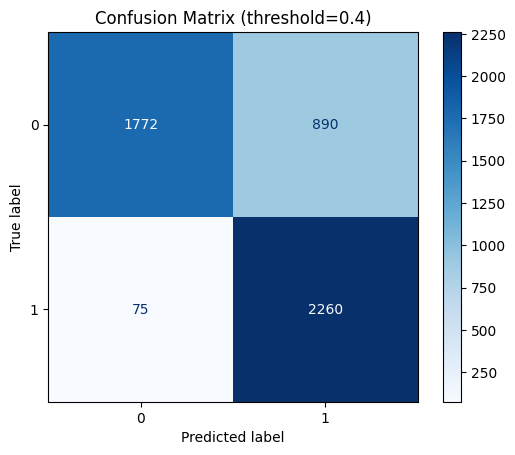

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

threshold = 0.4
y_test_pred = (lr_test_proba >= threshold).astype(int)

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={threshold})")
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Pipeline içindeki lojistik regresyon adımından katsayıları çekiyoruz
coefficients = lr_pipe.named_steps['lr'].coef_[0]
features = X_train.columns

# Katsayıları DataFrame yapalım
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
}).sort_values(by='Absolute_Importance', ascending=False)

print(importance_df)

                    Feature  Coefficient  Absolute_Importance
1  log_achievements_per_day    -6.297903             6.297903
0        total_achievements    -0.573635             0.573635
2             lifetime_days     0.444613             0.444613


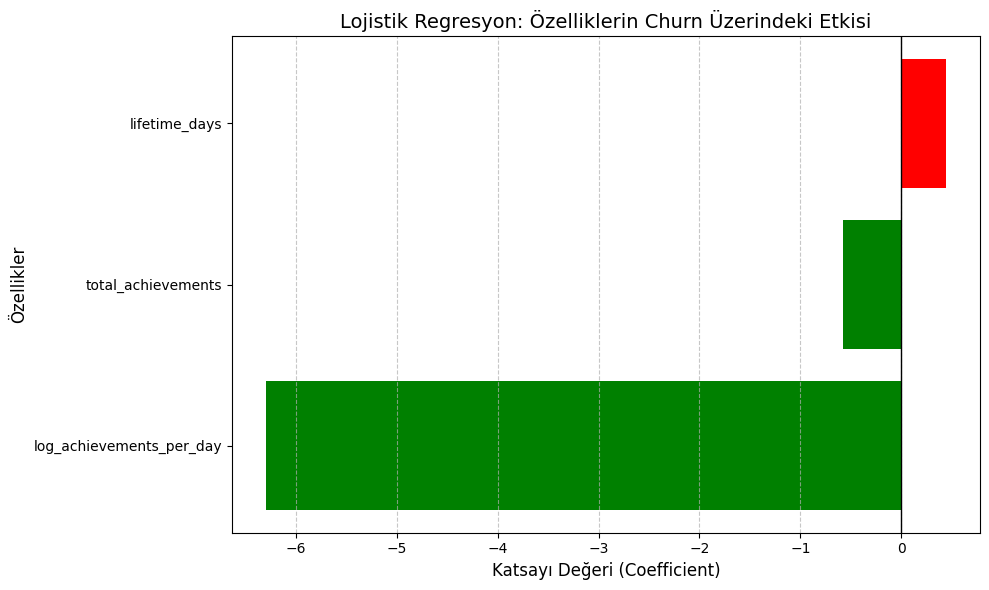

In [ ]:
import matplotlib.pyplot as plt

# Görselleştirme için veriyi hazırlayalım (Katsayılara göre sıralı kalsın)
importance_df = importance_df.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in importance_df['Coefficient']]

plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linestyle='-', linewidth=1) # 0 çizgisi

plt.title('Lojistik Regresyon: Özelliklerin Churn Üzerindeki Etkisi', fontsize=14)
plt.xlabel('Katsayı Değeri (Coefficient)', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Açıklama ekleyelim
#plt.text(0.1, len(importance_df)-1, 'Risk Artıranlar (+)', color='red', fontweight='bold')
#plt.text(-0.5, len(importance_df)-1, 'Risk Azaltanlar (-)', color='green', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Tüm DataFrame (X) için olasılıkları hesapla
all_probs = lr_pipe.predict_proba(X)[:, 1]

# Orijinal verinle birleştir
final_output = X.copy()

# 1. Olasılığı 100 ile çarpıp doğrudan 2 ondalığa yuvarlıyoruz
final_output['Churn_Probability_Pct'] = (all_probs * 100).round(2)

# 2. Risk Gruplarını belirleyelim (0-100 ölçeğinde)
final_output['Risk_Level'] = pd.cut(final_output['Churn_Probability_Pct'],
                                   bins=[0, 40, 70, 100],
                                   labels=['Düşük', 'Orta', 'Yüksek'],
                                   include_lowest=True)

# Sonucu görelim
print(final_output[['Churn_Probability_Pct', 'Risk_Level']].head())

# Tabloyu kontrol edelim
print(final_output[['Churn_Probability_Pct', 'Risk_Level']].head())

# Bu tabloyu dışa aktarıp Looker Studio'ya bağla
final_output.to_csv("churn_predictions.csv")
final_output

   Churn_Probability_Pct Risk_Level
0                   8.08      Düşük
1                   0.00      Düşük
2                   0.00      Düşük
3                  54.38       Orta
4                   0.02      Düşük
   Churn_Probability_Pct Risk_Level
0                   8.08      Düşük
1                   0.00      Düşük
2                   0.00      Düşük
3                  54.38       Orta
4                   0.02      Düşük


,total_achievements,log_achievements_per_day,lifetime_days,Churn_Probability_Pct,Risk_Level
0,2635,0.287682,5743,8.08,Düşük
1,101446,4.184084,5216,0.00,Düşük
2,23261,1.435085,4050,0.00,Düşük
3,1222,0.000000,1643,54.38,Orta
4,1702,0.757686,4503,0.02,Düşük
...,...,...,...,...,...
14986,2,0.000000,4798,78.75,Yüksek
14987,1,0.000000,4976,79.65,Yüksek
14988,2,0.000000,3812,73.23,Yüksek
14989,2,0.000000,4829,78.91,Yüksek


In [ ]:
import pandas as pd

# Proje ve Tablo Bilgileri
project_id = 'gamingprofilesproject' # Google Cloud Proje ID'n
table_id = 'stores.ml_churn_risks_output'

# DataFrame'i BigQuery'e gönder
final_output.to_gbq(table_id, project_id=project_id, if_exists='replace')

/tmp/ipython-input-956451502.py:8: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  final_output.to_gbq(table_id, project_id=project_id, if_exists='replace')
100%|██████████| 1/1 [00:00<00:00, 13400.33it/s]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Not Churn", "Churn"]
))


              precision    recall  f1-score   support

   Not Churn       0.96      0.67      0.79      2662
       Churn       0.72      0.97      0.82      2335

    accuracy                           0.81      4997
   macro avg       0.84      0.82      0.81      4997
weighted avg       0.85      0.81      0.80      4997



In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve

pr_auc = average_precision_score(y_test, lr_test_proba)
print(f"PR-AUC: {pr_auc:.4f}")


PR-AUC: 0.8403


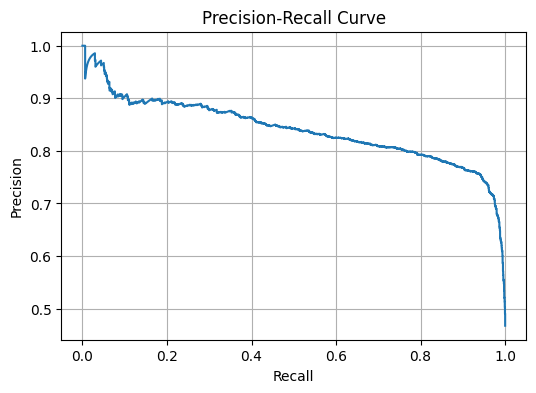

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, lr_test_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()


In [ ]:
X_new = pd.DataFrame([{
    "total_achievements": 1702	,
    "log_achievements_per_day": 0.0757686,
    "lifetime_days": 4503

}])

# 🔑 KRİTİK SATIR
X_new = X_new[lr_pipe.feature_names_in_]


churn_proba = lr_pipe.predict_proba(X_new)[0, 1]
print(f"Churn olasılığı: %{churn_proba*100:.2f}")



Churn olasılığı: %50.57


**Final: XGBoost**

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred  = (xgb_proba >= 0.5).astype(int)

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print("\nClassification report (thr=0.5):\n", classification_report(y_test, xgb_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, xgb_pred))

XGBoost ROC-AUC: 0.9131918491192563

Classification report (thr=0.5):
               precision    recall  f1-score   support

         0.0       0.93      0.79      0.85      2662
         1.0       0.79      0.94      0.86      2335

    accuracy                           0.86      4997
   macro avg       0.86      0.86      0.86      4997
weighted avg       0.87      0.86      0.86      4997

Confusion matrix:
 [[2094  568]
 [ 148 2187]]


**Feature Importance**

In [ ]:
import pandas as pd

importance = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importance.head(20)

,0
log_achievements_per_day,0.825803
total_achievements,0.091512
lifetime_days,0.082684


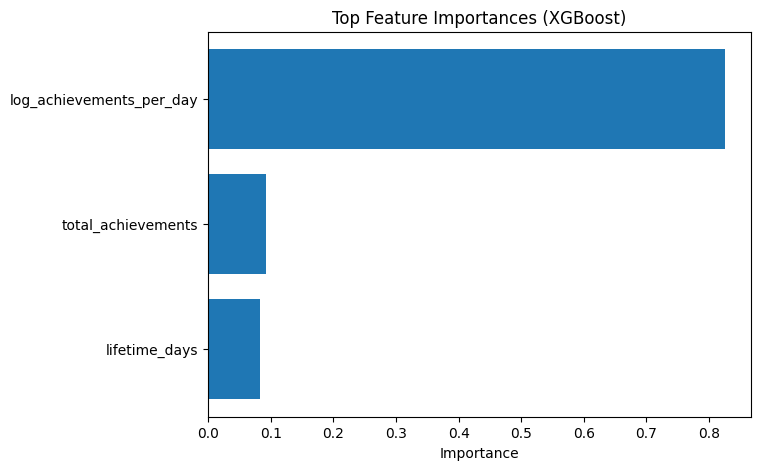

In [ ]:
import matplotlib.pyplot as plt

top = importance.head(15)[::-1]
plt.figure(figsize=(7,5))
plt.barh(top.index, top.values)
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

Threshold Tuning (0,2,-0,6)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
for t in thresholds:
    preds = (xgb_proba >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, preds, average="binary", zero_division=0)
    print(f"thr={t:.1f}  precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}")

thr=0.2  precision=0.774  recall=0.957  f1=0.855
thr=0.3  precision=0.781  recall=0.954  f1=0.859
thr=0.4  precision=0.784  recall=0.950  f1=0.859
thr=0.5  precision=0.794  recall=0.937  f1=0.859
thr=0.6  precision=0.810  recall=0.883  f1=0.844


Threshold Tuning (0.3 – 0.6)

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

rows = []

for t in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    preds = (xgb_proba >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_test, preds, average="binary", zero_division=0
    )
    rows.append({
        "threshold": t,
        "precision": round(p, 3),
        "recall": round(r, 3),
        "f1": round(f1, 3)
    })

thr_table = pd.DataFrame(rows)
thr_table

,threshold,precision,recall,f1
0,0.30,0.781,0.954,0.859
1,0.35,0.783,0.952,0.859
2,0.40,0.784,0.950,0.859
3,0.45,0.789,0.947,0.860
4,0.50,0.794,0.937,0.859
5,0.55,0.803,0.918,0.857
6,0.60,0.810,0.883,0.844


Görselleştirme – Trade-off

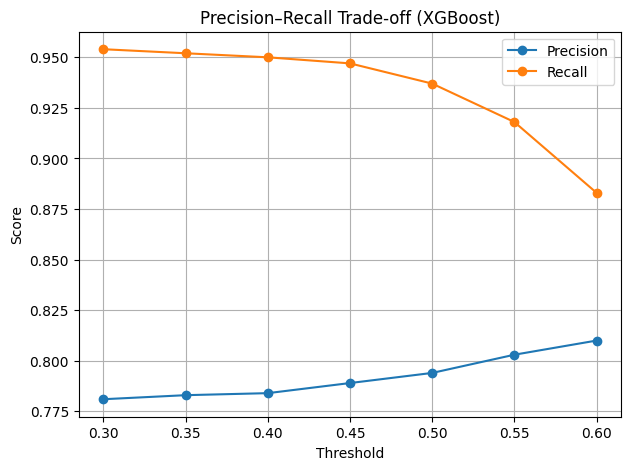

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(thr_table["threshold"], thr_table["precision"], marker="o", label="Precision")
plt.plot(thr_table["threshold"], thr_table["recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

**Final Skor Tablosu (Test set için)**

In [ ]:
test_rows = test_mask  # senin boolean mask'in

churn_scored = churn_ml.loc[test_rows, ["playerid", "obs_date", "churn_120"]].copy()
churn_scored["churn_probability"] = xgb_proba

churn_scored.sort_values("churn_probability", ascending=False).head(20)

,playerid,obs_date,churn_120,churn_probability
13966,3836585,2024-09-01,1,0.995982
14817,224594,2024-09-01,1,0.995105
14747,3477823,2024-09-01,1,0.994991
14575,4347199,2024-09-01,1,0.994803
14637,3527027,2024-09-01,1,0.994778
14766,3456826,2024-09-01,1,0.994778
14921,196644,2024-09-01,1,0.994698
13444,91890,2024-09-01,1,0.994591
14477,231534,2024-09-01,1,0.994567
14329,3441249,2024-09-01,1,0.994347


**Hızlı Segment-odaklı kontrol (Core/Casual/Dormant yoksa atla)**

In [ ]:
if "segment_ml" in churn_ml.columns:
    tmp = churn_ml.loc[test_mask, ["segment_ml", "churn_120"]].copy()
    print(tmp.groupby("segment_ml")["churn_120"].mean().mul(100).round(2))